# data preprocess by bert

In [ ]:
import json
import time
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer
import xgboost as xgb

# ==========================================
# 1. 載入資料並隨機抽取 800 筆
# ==========================================
# 載入真人爬蟲資料
with open("web_crawl_data.json", "r", encoding="utf-8") as f:
    real_data = json.load(f)
df_real = pd.DataFrame(real_data)

# 載入 AI 生成資料
with open("ai_generated_data.json", "r", encoding="utf-8") as f:
    ai_data = json.load(f)
df_ai = pd.DataFrame(ai_data)

# 隨機抽取 800 筆，並打上新標籤 (0 = 真人, 1 = AI)
# random_state=42 確保每次隨機抽取的結果都一樣，方便寫報告
df_real_sampled = df_real.sample(n=1000, random_state=42).copy()
df_real_sampled["label"] = 0

df_ai_sampled = df_ai.sample(n=1000, random_state=42).copy()
df_ai_sampled["label"] = 1

df = pd.concat([df_real_sampled, df_ai_sampled], ignore_index=True)

print(f"資料準備完成！真人：{len(df_real_sampled)} 筆，AI：{len(df_ai_sampled)} 筆")
print(f"資料集總筆數：{len(df)}")

# ==========================================
# 2. BERT 特徵提取 (總共 1600 筆)
# ==========================================
df["full_text"] = (df["title"] + " " + df["content"]).astype(str)

model_name = "bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()


def get_bert_embeddings(text_list, batch_size=16):
    embeddings = []
    total = len(text_list)
    for i in range(0, total, batch_size):
        batch_texts = text_list[i : i + batch_size].tolist()
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt",
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = bert_model(**inputs)
            # 取得 [CLS] token 的 embedding
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(batch_embeddings)

        if (i + batch_size) % 160 == 0 or (i + batch_size) >= total:
            print(f"BERT 提取進度: {min(i + batch_size, total)}/{total}")

    return np.vstack(embeddings)


print("\n開始提取 BERT 特徵...")
start_bert = time.time()
X_text_bert = get_bert_embeddings(df["full_text"])
print(f"BERT 特徵提取完成，耗時: {time.time() - start_bert:.2f} 秒")


# 3. Metadata 處理 (看板分類與字數)

le = LabelEncoder()
df["class_encoded"] = le.fit_transform(df["classification"])
df["text_len_log"] = np.log1p(df["content"].apply(len))

X_meta = df[["class_encoded", "text_len_log"]].values

# 合併特徵
X = np.hstack((X_text_bert, X_meta))
y = df["label"].values

print(f"最終特徵維度: {X.shape}")  # 預期會是 (1600, 770) 左右

資料準備完成！真人：1000 筆，AI：1000 筆
資料集總筆數：2000


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2662.95it/s]
BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



開始提取 BERT 特徵...
BERT 提取進度: 160/2000
BERT 提取進度: 320/2000
BERT 提取進度: 480/2000
BERT 提取進度: 640/2000
BERT 提取進度: 800/2000
BERT 提取進度: 960/2000
BERT 提取進度: 1120/2000
BERT 提取進度: 1280/2000
BERT 提取進度: 1440/2000
BERT 提取進度: 1600/2000
BERT 提取進度: 1760/2000
BERT 提取進度: 1920/2000
BERT 提取進度: 2000/2000
BERT 特徵提取完成，耗時: 464.57 秒
最終特徵維度: (2000, 770)


# model training  real vs ai text


==================== Random Forest 訓練中 ====================
Fold 1/5 Precision: 0.9381
Fold 2/5 Precision: 0.9471
Fold 3/5 Precision: 0.9381
Fold 4/5 Precision: 0.9340
Fold 5/5 Precision: 0.9213

==================== XGBoost 訓練中 ====================
Fold 1/5 Precision: 0.9242
Fold 2/5 Precision: 0.9510
Fold 3/5 Precision: 0.9505
Fold 4/5 Precision: 0.9426
Fold 5/5 Precision: 0.9384

==================== Deep Learning (MLP) 訓練中 ====================
Fold 1/5 Precision: 0.9803
Fold 2/5 Precision: 0.9704
Fold 3/5 Precision: 0.9662
Fold 4/5 Precision: 0.9706
Fold 5/5 Precision: 0.9608

============================== 跨模型核心指標比較表 ==============================
             Method  Fold 1 Prec.  Fold 2 Prec.  Fold 3 Prec.  Fold 4 Prec.  Fold 5 Prec.  Final Precision  Final Recall  Final F1  Final AUROC
      Random Forest        0.9381        0.9471        0.9381        0.9340        0.9213           0.9356         0.988    0.9611       0.9936
            XGBoost        0.9242        0.9510   

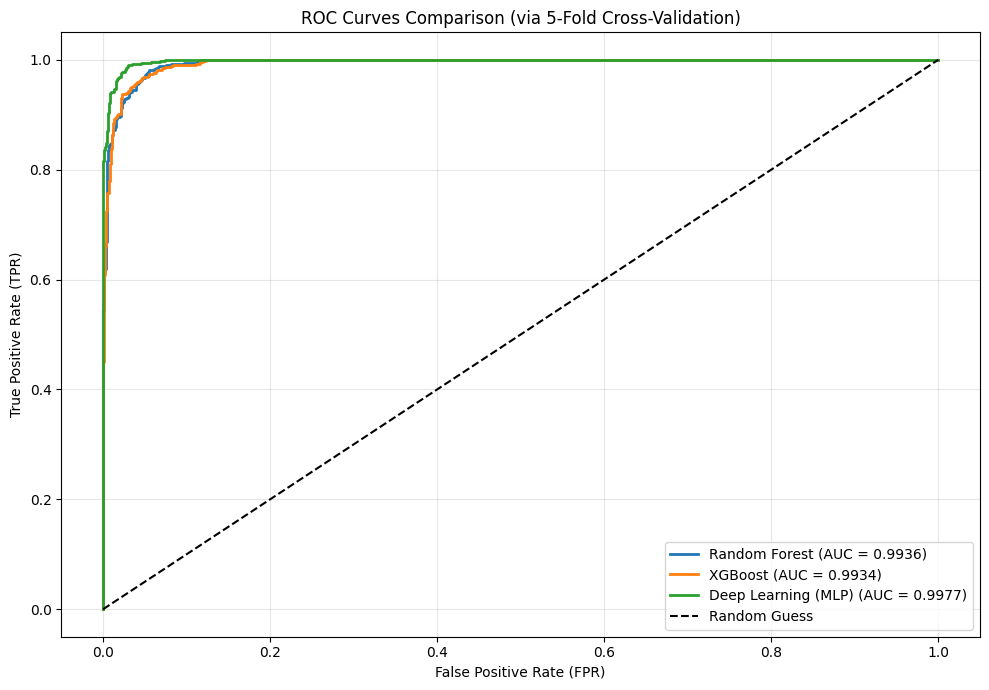

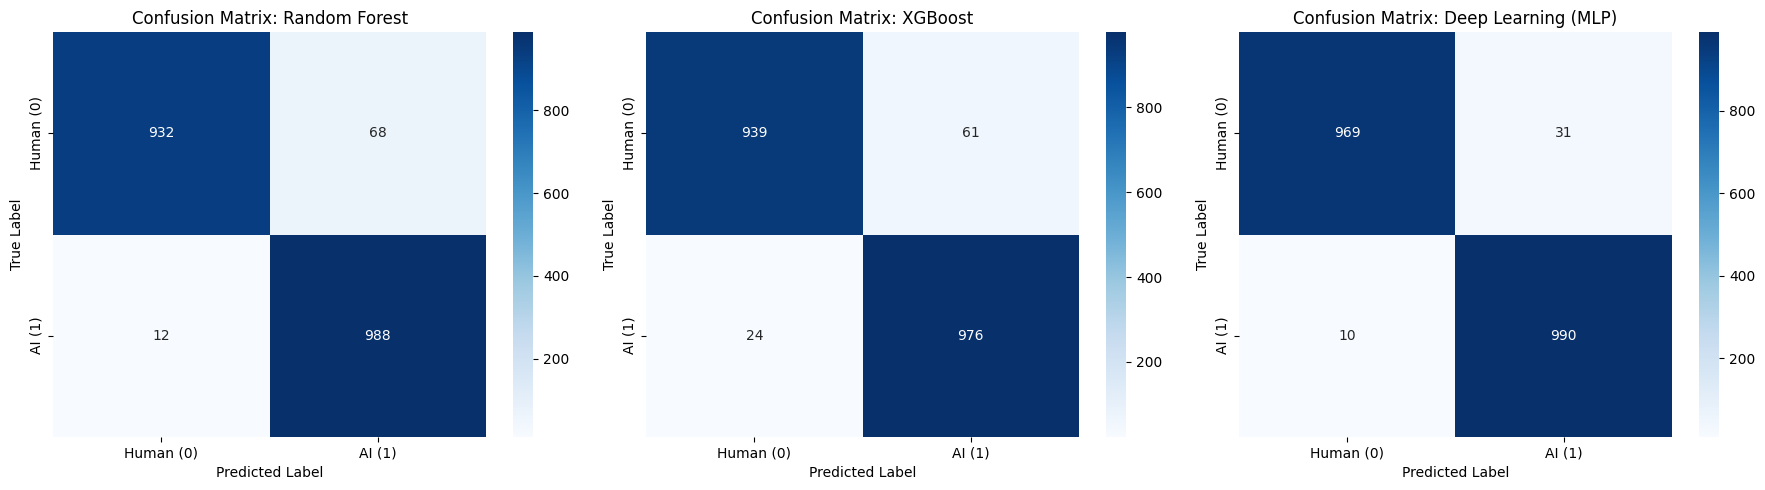

In [11]:
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import class_weight
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer
import xgboost as xgb

# 假設 X, y 已經準備好 (1600 筆平衡資料，0=真人, 1=AI)

# ==========================================
# 4. 深度學習模型定義
# ==========================================
class AdvancedMLP(nn.Module):

    def __init__(self, input_dim):
        super(AdvancedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# 5. 嚴謹交叉驗證、指標紀錄與繪圖
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic",
        learning_rate=0.03,
        n_estimators=300,
        max_depth=6,
        random_state=42,
        eval_metric="logloss",
    ),
    "Deep Learning (MLP)": "torch_mlp",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 用來儲存繪圖與表格數據的字典
roc_data = {}
final_auroc_scores = {}  # 🌟 修正點：用來存精確的 AUC 數值，畫圖時直接拿
cm_data = {}
summary_list = []

for name, model_obj in models.items():
    print(f"\n{'='*20} {name} 訓練中 {'='*20}")

    # 用來收集全樣本預測結果以計算最終嚴謹 CV 指標
    y_pred_all = np.zeros_like(y)
    y_prob_all = np.zeros(len(y), dtype=float)

    fold_precisions = []
    start_time = time.time()

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # 樹狀模型以外需要特徵標準化
        if name != "Random Forest":
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # ---- A. 隨機森林 ----
        if name == "Random Forest":
            model_obj.fit(X_train, y_train)
            y_pred = model_obj.predict(X_test)
            y_prob = model_obj.predict_proba(X_test)[:, 1]

        # ---- B. XGBoost ----
        elif name == "XGBoost":
            model_obj.fit(X_train, y_train)
            y_pred = model_obj.predict(X_test)
            y_prob = model_obj.predict_proba(X_test)[:, 1]

        # ---- C. 深度學習 ----
        elif name == "Deep Learning (MLP)":
            X_train_t = torch.FloatTensor(X_train)
            y_train_t = torch.LongTensor(y_train)
            X_test_t = torch.FloatTensor(X_test).to(device)

            train_dataset = TensorDataset(X_train_t, y_train_t)
            train_loader = DataLoader(
                train_dataset, batch_size=32, shuffle=True
            )

            mlp_net = AdvancedMLP(X.shape[1]).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.AdamW(mlp_net.parameters(), lr=0.001)

            mlp_net.train()
            for epoch in range(30):
                for batch_X, batch_y in train_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    optimizer.zero_grad()
                    outputs = mlp_net(batch_X)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()

            mlp_net.eval()
            with torch.no_grad():
                test_outputs = mlp_net(X_test_t)
                probs = torch.softmax(test_outputs, dim=1)
                y_prob = probs[:, 1].cpu().numpy()
                _, y_pred_tensor = torch.max(test_outputs, 1)
                y_pred = y_pred_tensor.cpu().numpy()

        # 儲存當前 Fold 的數據
        y_pred_all[test_idx] = y_pred
        y_prob_all[test_idx] = y_prob

        # 計算當前 Fold 的 Precision
        current_fold_precision = precision_score(y_test, y_pred)
        fold_precisions.append(current_fold_precision)
        print(f"Fold {fold+1}/5 Precision: {current_fold_precision:.4f}")

    # 計算基於完整 Cross-Validation 預測結果的最終核心指標
    final_precision = precision_score(y, y_pred_all)
    final_recall = recall_score(y, y_pred_all)
    final_f1 = f1_score(y, y_pred_all)
    final_auroc = roc_auc_score(y, y_prob_all)

    # 將數據存入字典，給繪圖用
    final_auroc_scores[name] = final_auroc

    # 將此模型的數據存入列表 (Table data)
    summary_list.append(
        {
            "Method": name,
            "Fold 1 Prec.": fold_precisions[0],
            "Fold 2 Prec.": fold_precisions[1],
            "Fold 3 Prec.": fold_precisions[2],
            "Fold 4 Prec.": fold_precisions[3],
            "Fold 5 Prec.": fold_precisions[4],
            "Final Precision": final_precision,
            "Final Recall": final_recall,
            "Final F1": final_f1,
            "Final AUROC": final_auroc,
        }
    )

    # 紀錄用於畫圖的數據
    roc_data[name] = roc_curve(y, y_prob_all)
    cm_data[name] = confusion_matrix(y, y_pred_all)

# ==========================================
# 6. 輸出數據比較表格
# ==========================================
df_summary = pd.DataFrame(summary_list)
print("\n" + "=" * 30 + " 跨模型核心指標比較表 " + "=" * 30)
pd.set_option("display.precision", 4)
print(df_summary.to_string(index=False))

# ==========================================
# 7. 繪製圖表 (ROC Curve 與 Confusion Matrix)
# ==========================================
# (A) 繪製 ROC 曲線 (三模型合一)
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, _) in roc_data.items():
    # 🌟 修正點：直接拿存好的 float 數值，不會再報 array-like 錯
    auc_score = final_auroc_scores[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves Comparison (via 5-Fold Cross-Validation)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (B) 繪製三種模型的混淆矩陣
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ["Human (0)", "AI (1)"]

for i, (name, cm) in enumerate(cm_data.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i],
    )
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# tf-idf method

資料準備完成！真人：1000 筆，AI：1000 筆
資料集總筆數：2000
Dataset ready! Feature shape: (2000, 1002)

==================== Random Forest 訓練中 ====================
Fold 1/5 Precision: 0.9454
Fold 2/5 Precision: 0.9487
Fold 3/5 Precision: 0.9385
Fold 4/5 Precision: 0.9200
Fold 5/5 Precision: 0.9124

==================== XGBoost 訓練中 ====================
Fold 1/5 Precision: 0.8969
Fold 2/5 Precision: 0.9403
Fold 3/5 Precision: 0.9296
Fold 4/5 Precision: 0.9015
Fold 5/5 Precision: 0.8571

==================== Deep Learning (MLP) 訓練中 ====================
Fold 1/5 Precision: 0.8990
Fold 2/5 Precision: 0.8894
Fold 3/5 Precision: 0.9223
Fold 4/5 Precision: 0.8393
Fold 5/5 Precision: 0.8416

============================== 跨模型核心指標比較表 ==============================
             Method  Fold 1 Prec.  Fold 2 Prec.  Fold 3 Prec.  Fold 4 Prec.  Fold 5 Prec.  Final Precision  Final Recall  Final F1  Final AUROC
      Random Forest        0.9454        0.9487        0.9385        0.9200        0.9124           0.9328      

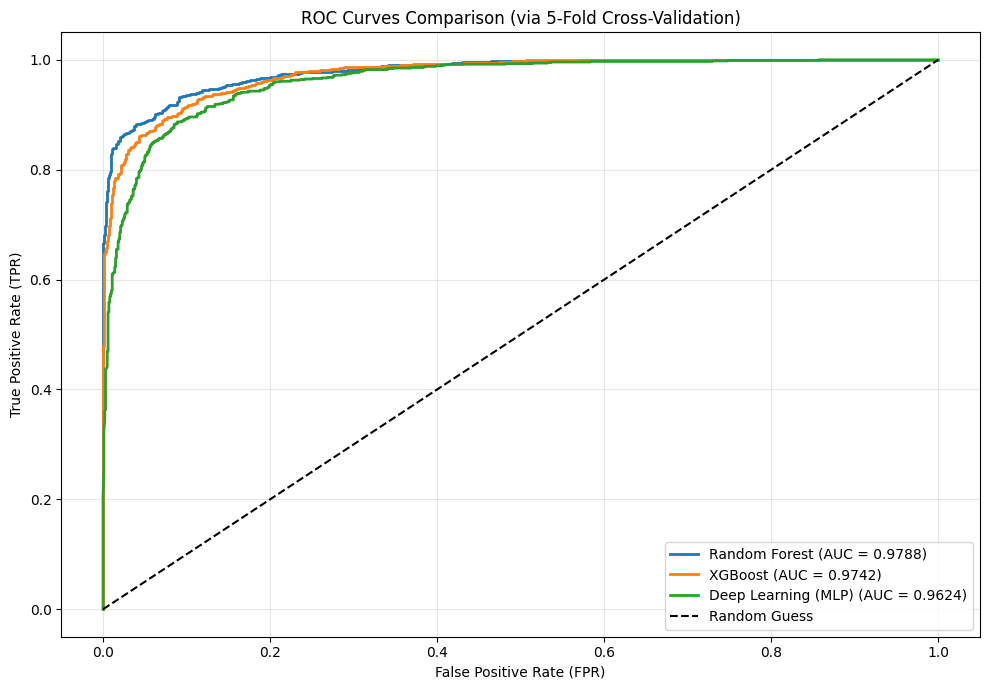

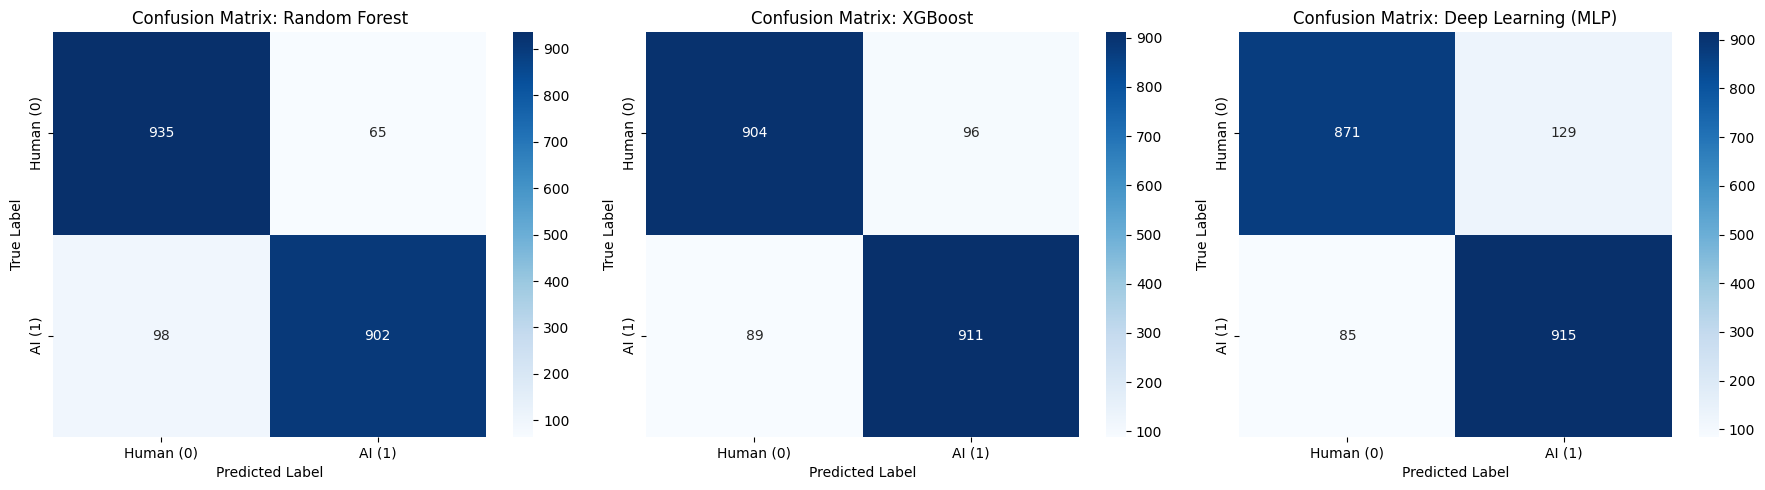

In [14]:
import pandas as pd
import jieba
import json
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer
import xgboost as xgb

# ==========================================
# 1. 載入資料並隨機抽取 800 筆
# ==========================================
# 載入真人爬蟲資料

# 載入真人爬蟲資料
with open("web_crawl_data.json", "r", encoding="utf-8") as f:
    real_data = json.load(f)
df_real = pd.DataFrame(real_data)

# 載入 AI 生成資料
with open("ai_generated_data.json", "r", encoding="utf-8") as f:
    ai_data = json.load(f)
df_ai = pd.DataFrame(ai_data)

# 隨機抽取 800 筆，並打上新標籤 (0 = 真人, 1 = AI)
# random_state=42 確保每次隨機抽取的結果都一樣，方便寫報告
df_real_sampled = df_real.sample(n=1000, random_state=42).copy()
df_real_sampled["label"] = 0

df_ai_sampled = df_ai.sample(n=1000, random_state=42).copy()
df_ai_sampled["label"] = 1
df = pd.concat([df_real_sampled, df_ai_sampled], ignore_index=True)

print(f"資料準備完成！真人：{len(df_real_sampled)} 筆，AI：{len(df_ai_sampled)} 筆")
print(f"資料集總筆數：{len(df)}")
# ==========================================
# 4. Text Processing
# ==========================================
def tokenize(text):
    words = jieba.cut(str(text))
    return " ".join([w for w in words if len(w) > 1])

df['full_text'] = df['title'].astype(str) + " " + df['content'].astype(str)
df['tokenized_text'] = df['full_text'].apply(tokenize)

# ==========================================
# 5. Encoding
# ==========================================
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['classification'])

# ==========================================
# 6. TF-IDF
# ==========================================
tfidf = TfidfVectorizer(max_features=1000)
X_text = tfidf.fit_transform(df['tokenized_text']).toarray()

# ==========================================
# 7. Combine features
# ==========================================
df['text_len'] = df['content'].astype(str).apply(len)

X_meta = df[['class_encoded','text_len']].values
X = np.hstack((X_text, X_meta))
y = df['label'].values

print(f"Dataset ready! Feature shape: {X.shape}")

import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import class_weight
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer
import xgboost as xgb

# 假設 X, y 已經準備好 (1600 筆平衡資料，0=真人, 1=AI)

# ==========================================
# 4. 深度學習模型定義
# ==========================================
class AdvancedMLP(nn.Module):

    def __init__(self, input_dim):
        super(AdvancedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# 5. 嚴謹交叉驗證、指標紀錄與繪圖
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic",
        learning_rate=0.03,
        n_estimators=300,
        max_depth=6,
        random_state=42,
        eval_metric="logloss",
    ),
    "Deep Learning (MLP)": "torch_mlp",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 用來儲存繪圖與表格數據的字典
roc_data = {}
final_auroc_scores = {}  # 🌟 修正點：用來存精確的 AUC 數值，畫圖時直接拿
cm_data = {}
summary_list = []

for name, model_obj in models.items():
    print(f"\n{'='*20} {name} 訓練中 {'='*20}")

    # 用來收集全樣本預測結果以計算最終嚴謹 CV 指標
    y_pred_all = np.zeros_like(y)
    y_prob_all = np.zeros(len(y), dtype=float)

    fold_precisions = []
    start_time = time.time()

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # 樹狀模型以外需要特徵標準化
        if name != "Random Forest":
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # ---- A. 隨機森林 ----
        if name == "Random Forest":
            model_obj.fit(X_train, y_train)
            y_pred = model_obj.predict(X_test)
            y_prob = model_obj.predict_proba(X_test)[:, 1]

        # ---- B. XGBoost ----
        elif name == "XGBoost":
            model_obj.fit(X_train, y_train)
            y_pred = model_obj.predict(X_test)
            y_prob = model_obj.predict_proba(X_test)[:, 1]

        # ---- C. 深度學習 ----
        elif name == "Deep Learning (MLP)":
            X_train_t = torch.FloatTensor(X_train)
            y_train_t = torch.LongTensor(y_train)
            X_test_t = torch.FloatTensor(X_test).to(device)

            train_dataset = TensorDataset(X_train_t, y_train_t)
            train_loader = DataLoader(
                train_dataset, batch_size=32, shuffle=True
            )

            mlp_net = AdvancedMLP(X.shape[1]).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.AdamW(mlp_net.parameters(), lr=0.001)

            mlp_net.train()
            for epoch in range(30):
                for batch_X, batch_y in train_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    optimizer.zero_grad()
                    outputs = mlp_net(batch_X)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()

            mlp_net.eval()
            with torch.no_grad():
                test_outputs = mlp_net(X_test_t)
                probs = torch.softmax(test_outputs, dim=1)
                y_prob = probs[:, 1].cpu().numpy()
                _, y_pred_tensor = torch.max(test_outputs, 1)
                y_pred = y_pred_tensor.cpu().numpy()

        # 儲存當前 Fold 的數據
        y_pred_all[test_idx] = y_pred
        y_prob_all[test_idx] = y_prob

        # 計算當前 Fold 的 Precision
        current_fold_precision = precision_score(y_test, y_pred)
        fold_precisions.append(current_fold_precision)
        print(f"Fold {fold+1}/5 Precision: {current_fold_precision:.4f}")

    # 計算基於完整 Cross-Validation 預測結果的最終核心指標
    final_precision = precision_score(y, y_pred_all)
    final_recall = recall_score(y, y_pred_all)
    final_f1 = f1_score(y, y_pred_all)
    final_auroc = roc_auc_score(y, y_prob_all)

    # 將數據存入字典，給繪圖用
    final_auroc_scores[name] = final_auroc

    # 將此模型的數據存入列表 (Table data)
    summary_list.append(
        {
            "Method": name,
            "Fold 1 Prec.": fold_precisions[0],
            "Fold 2 Prec.": fold_precisions[1],
            "Fold 3 Prec.": fold_precisions[2],
            "Fold 4 Prec.": fold_precisions[3],
            "Fold 5 Prec.": fold_precisions[4],
            "Final Precision": final_precision,
            "Final Recall": final_recall,
            "Final F1": final_f1,
            "Final AUROC": final_auroc,
        }
    )

    # 紀錄用於畫圖的數據
    roc_data[name] = roc_curve(y, y_prob_all)
    cm_data[name] = confusion_matrix(y, y_pred_all)

# ==========================================
# 6. 輸出數據比較表格
# ==========================================
df_summary = pd.DataFrame(summary_list)
print("\n" + "=" * 30 + " 跨模型核心指標比較表 " + "=" * 30)
pd.set_option("display.precision", 4)
print(df_summary.to_string(index=False))

# ==========================================
# 7. 繪製圖表 (ROC Curve 與 Confusion Matrix)
# ==========================================
# (A) 繪製 ROC 曲線 (三模型合一)
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, _) in roc_data.items():
    # 🌟 修正點：直接拿存好的 float 數值，不會再報 array-like 錯
    auc_score = final_auroc_scores[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves Comparison (via 5-Fold Cross-Validation)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (B) 繪製三種模型的混淆矩陣
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ["Human (0)", "AI (1)"]

for i, (name, cm) in enumerate(cm_data.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i],
    )
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.tight_layout()
plt.show()




# experiment 2 training data sensitive

In [18]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel

# ==========================================
# 0. 設備設定與 AdvancedMLP 定義
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class AdvancedMLP(nn.Module):
    def __init__(self, input_dim):
        super(AdvancedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 1. BERT 特徵萃取 (取代 TF-IDF)
# ==========================================
print("\n" + "="*25 + " 開始擷取 BERT 特徵 (這可能需要幾分鐘) " + "="*25)

# 載入中文 BERT 模型
tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
bert_model = AutoModel.from_pretrained("bert-base-chinese").to(device)

def get_bert_embeddings(text_list, batch_size=16):
    bert_model.eval()
    all_embeddings = []
    
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i : i + batch_size].tolist()
        
        # 將文字轉換為 BERT 接受的格式 (截斷過長文字至 512 tokens)
        inputs = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=512, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = bert_model(**inputs)
            
        # 取得 [CLS] token 的向量作為整句/整篇的語意表徵 (shape: batch_size, 768)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
        
        if (i + batch_size) % 160 == 0:
            print(f"已處理 {i + batch_size} 筆資料...")
            
    return np.vstack(all_embeddings)

# 假設你的 DataFrame 叫做 df，且有 'full_text', 'class_encoded', 'text_len', 'label'
X_text_bert = get_bert_embeddings(df['full_text'].astype(str))

# 結合 BERT 向量與 Metadata
X_meta = df[['class_encoded', 'text_len']].values
X = np.hstack((X_text_bert, X_meta))
y = df['label'].values

print(f"BERT 特徵準備完成！最終特徵維度: {X.shape}") # 應該會是 (2000, 770)

# ==========================================
# 2. 輔助函式：確保取樣資料時類別絕對平衡 (50/50)
# ==========================================
def get_balanced_subset(X, y, size, random_state=42):
    np.random.seed(random_state)
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    half_size = size // 2
    sampled_idx_0 = np.random.choice(idx_0, half_size, replace=False)
    sampled_idx_1 = np.random.choice(idx_1, half_size, replace=False)

    subset_indices = np.concatenate([sampled_idx_0, sampled_idx_1])
    np.random.shuffle(subset_indices)

    return X[subset_indices], y[subset_indices]

# ==========================================
# 3. 實驗設定與主迴圈
# ==========================================
data_sizes = [200, 400, 800, 1600]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []

for size in data_sizes:
    print(f"\n{'='*25} 正在測試資料量大小: {size} 筆 {'='*25}")

    X_sub, y_sub = get_balanced_subset(X, y, size)

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=12, random_state=42
        ),
        "XGBoost": xgb.XGBClassifier(
            objective="binary:logistic",
            learning_rate=0.03,
            n_estimators=300,
            max_depth=6,
            random_state=42,
            eval_metric="logloss",
        ),
        "Deep Learning (MLP)": "torch_mlp",
    }

    for name, model_obj in models.items():
        fold_precisions = []
        y_pred_all = np.zeros_like(y_sub)
        y_prob_all = np.zeros(len(y_sub), dtype=float)

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub)):
            X_train, X_test = X_sub[train_idx], X_sub[test_idx]
            y_train, y_test = y_sub[train_idx], y_sub[test_idx]

            if name != "Random Forest":
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            if name == "Random Forest":
                model_obj.fit(X_train, y_train)
                y_pred = model_obj.predict(X_test)
                y_prob = model_obj.predict_proba(X_test)[:, 1]

            elif name == "XGBoost":
                model_obj.fit(X_train, y_train)
                y_pred = model_obj.predict(X_test)
                y_prob = model_obj.predict_proba(X_test)[:, 1]

            elif name == "Deep Learning (MLP)":
                X_train_t = torch.FloatTensor(X_train)
                y_train_t = torch.LongTensor(y_train)
                X_test_t = torch.FloatTensor(X_test).to(device)

                train_dataset = TensorDataset(X_train_t, y_train_t)
                train_loader = DataLoader(
                    train_dataset, batch_size=16, shuffle=True
                )

                mlp_net = AdvancedMLP(X_sub.shape[1]).to(device)
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.AdamW(mlp_net.parameters(), lr=0.001)

                mlp_net.train()
                for epoch in range(30):
                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                        optimizer.zero_grad()
                        outputs = mlp_net(batch_X)
                        loss = criterion(outputs, batch_y)
                        loss.backward()
                        optimizer.step()

                mlp_net.eval()
                with torch.no_grad():
                    test_outputs = mlp_net(X_test_t)
                    probs = torch.softmax(test_outputs, dim=1)
                    y_prob = probs[:, 1].cpu().numpy()
                    _, y_pred_tensor = torch.max(test_outputs, 1)
                    y_pred = y_pred_tensor.cpu().numpy()

            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            fold_precisions.append(precision_score(y_test, y_pred))

        avg_precision = np.mean(fold_precisions)
        final_accuracy = accuracy_score(y_sub, y_pred_all)
        final_recall = recall_score(y_sub, y_pred_all)
        final_f1 = f1_score(y_sub, y_pred_all)
        final_auroc = roc_auc_score(y_sub, y_prob_all)

        results_list.append(
            {
                "Data Size": size,
                "Model": name,
                "Avg Precision": avg_precision,
                "Final Accuracy": final_accuracy,
                "Final Recall": final_recall,
                "Final F1-score": final_f1,
                "Final AUROC": final_auroc,
            }
        )

# ==========================================
# 4. 輸出最終實驗比較表
# ==========================================
df_results = pd.DataFrame(results_list)
print("\n" + "=" * 25 + " 實驗二 (BERT)：資料量敏感度結果總表 " + "=" * 25)
pd.set_option("display.precision", 4)

df_pivot = df_results.pivot(
    index="Data Size", columns="Model", values="Avg Precision"
)
print("--- 跨模型在不同資料量下的【平均 Precision】對比 ---")
print(df_pivot)

print("\n--- 所有核心指標詳細數據 ---")
print(df_results.to_string(index=False))

Using device: cpu

========================= 開始擷取 BERT 特徵 (這可能需要幾分鐘) =========================


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5626.67it/s]
BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


已處理 160 筆資料...
已處理 320 筆資料...
已處理 480 筆資料...
已處理 640 筆資料...
已處理 800 筆資料...
已處理 960 筆資料...
已處理 1120 筆資料...
已處理 1280 筆資料...
已處理 1440 筆資料...
已處理 1600 筆資料...
已處理 1760 筆資料...
已處理 1920 筆資料...
BERT 特徵準備完成！最終特徵維度: (2000, 770)

========================= 正在測試資料量大小: 200 筆 =========================

========================= 正在測試資料量大小: 400 筆 =========================

========================= 正在測試資料量大小: 800 筆 =========================

========================= 正在測試資料量大小: 1600 筆 =========================

========================= 實驗二 (BERT)：資料量敏感度結果總表 =========================
--- 跨模型在不同資料量下的【平均 Precision】對比 ---
Model      Deep Learning (MLP)  Random Forest  XGBoost
Data Size                                             
200                     0.9446         0.9173   0.9189
400                     0.9485         0.9345   0.9241
800                     0.9520         0.9321   0.9281
1600                    0.9624         0.9294   0.9468

--- 所有核心指標詳細數據 ---
 Data Size               Model  Avg Prec

#  experiment 3 data imbalance

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. 建立 9:1 的不平衡資料集 (總數 1000 筆)
# ==========================================
def get_imbalanced_subset(X, y, majority_size=900, minority_size=100, random_state=42):
    np.random.seed(random_state)
    idx_0 = np.where(y == 0)[0] # 假設 0 是人類
    idx_1 = np.where(y == 1)[0] # 假設 1 是 AI

    # 隨機抽取 900 筆多數類，100 筆少數類
    sampled_idx_0 = np.random.choice(idx_0, majority_size, replace=False)
    sampled_idx_1 = np.random.choice(idx_1, minority_size, replace=False)

    subset_indices = np.concatenate([sampled_idx_0, sampled_idx_1])
    np.random.shuffle(subset_indices)  # 打亂順序

    return X[subset_indices], y[subset_indices]

print("\n" + "="*25 + " 準備 9:1 不平衡資料集 " + "="*25)
# 建立 900 vs 100 的資料集 (如果你的 y=1 是多數類，請自行反轉數量)
X_imb, y_imb = get_imbalanced_subset(X, y, majority_size=900, minority_size=100)
print(f"不平衡資料集維度: {X_imb.shape}")
print(f"類別分佈: 類別 0: {np.sum(y_imb==0)} 筆, 類別 1: {np.sum(y_imb==1)} 筆")

# ==========================================
# 2. 實驗設定
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

conditions = ["1. Baseline", "2. Algorithmic Weighting", "3. Resampling (SMOTE)"]
models_names = ["Random Forest", "XGBoost", "Deep Learning (MLP)"]

results_list_exp3 = []

# ==========================================
# 3. 實驗主迴圈
# ==========================================
for condition in conditions:
    print(f"\n{'='*20} 測試情境: {condition} {'='*20}")

    for name in models_names:
        fold_f1 = []
        fold_auroc = []
        fold_recall = []
        
        y_pred_all = np.zeros_like(y_imb)
        y_prob_all = np.zeros(len(y_imb), dtype=float)

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_imb, y_imb)):
            X_train, X_test = X_imb[train_idx], X_imb[test_idx]
            y_train, y_test = y_imb[train_idx], y_imb[test_idx]

            # ----------------------------------------------------
            # 條件 3: Resampling (SMOTE) - 只對 Training set 進行!
            # ----------------------------------------------------
            if condition == "3. Resampling (SMOTE)":
                smote = SMOTE(random_state=42)
                X_train, y_train = smote.fit_resample(X_train, y_train)

            # 標準化 (MLP 必備，樹狀模型不影響)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # ----------------------------------------------------
            # 模型初始化與條件設定
            # ----------------------------------------------------
            if name == "Random Forest":
                # 條件 2: Class Weighting
                cw = "balanced" if condition == "2. Algorithmic Weighting" else None
                model_obj = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight=cw)
                
                model_obj.fit(X_train, y_train)
                y_pred = model_obj.predict(X_test)
                y_prob = model_obj.predict_proba(X_test)[:, 1]

            elif name == "XGBoost":
                # 條件 2: Class Weighting (scale_pos_weight = negative_count / positive_count)
                # 這裡的比例是 900/100 = 9.0
                spw = 9.0 if condition == "2. Algorithmic Weighting" else 1.0
                model_obj = xgb.XGBClassifier(
                    objective="binary:logistic", learning_rate=0.03, n_estimators=300,
                    max_depth=6, random_state=42, eval_metric="logloss", scale_pos_weight=spw
                )
                
                model_obj.fit(X_train, y_train)
                y_pred = model_obj.predict(X_test)
                y_prob = model_obj.predict_proba(X_test)[:, 1]

            elif name == "Deep Learning (MLP)":
                X_train_t = torch.FloatTensor(X_train)
                y_train_t = torch.LongTensor(y_train)
                X_test_t = torch.FloatTensor(X_test).to(device)

                train_dataset = TensorDataset(X_train_t, y_train_t)
                train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

                mlp_net = AdvancedMLP(X_imb.shape[1]).to(device)
                
                # 條件 2: Class Weighting (針對 CrossEntropyLoss 給予權重)
                if condition == "2. Algorithmic Weighting":
                    # 給予少數類(1) 9 倍的 Loss 懲罰
                    class_weights = torch.FloatTensor([1.0, 9.0]).to(device)
                    criterion = nn.CrossEntropyLoss(weight=class_weights)
                else:
                    criterion = nn.CrossEntropyLoss()
                    
                optimizer = optim.AdamW(mlp_net.parameters(), lr=0.001)

                mlp_net.train()
                for epoch in range(30):
                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                        optimizer.zero_grad()
                        outputs = mlp_net(batch_X)
                        loss = criterion(outputs, batch_y)
                        loss.backward()
                        optimizer.step()

                mlp_net.eval()
                with torch.no_grad():
                    test_outputs = mlp_net(X_test_t)
                    probs = torch.softmax(test_outputs, dim=1)
                    y_prob = probs[:, 1].cpu().numpy()
                    _, y_pred_tensor = torch.max(test_outputs, 1)
                    y_pred = y_pred_tensor.cpu().numpy()

            # 紀錄當前 Fold 的預測結果
            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob

        # 計算 5-Fold 完畢後的整體指標
        final_accuracy = accuracy_score(y_imb, y_pred_all)
        final_precision = precision_score(y_imb, y_pred_all)
        final_recall = recall_score(y_imb, y_pred_all)
        final_f1 = f1_score(y_imb, y_pred_all)
        final_auroc = roc_auc_score(y_imb, y_prob_all)

        results_list_exp3.append({
            "Condition": condition,
            "Model": name,
            "Accuracy": final_accuracy,
            "Precision": final_precision,
            "Recall": final_recall,
            "F1-score": final_f1,
            "AUROC": final_auroc,
        })

# ==========================================
# 4. 輸出最終實驗比較表
# ==========================================
df_exp3 = pd.DataFrame(results_list_exp3)
print("\n" + "=" * 25 + " 實驗三：資料不平衡處理結果總表 " + "=" * 25)
pd.set_option("display.precision", 4)

# 針對最關鍵的 F1-score 建立 Pivot Table
df_pivot_f1 = df_exp3.pivot(index="Condition", columns="Model", values="F1-score")
print("--- 不同處理策略下的【整體 F1-score】對比 ---")
print(df_pivot_f1)

# 針對 AUROC 建立 Pivot Table
df_pivot_auc = df_exp3.pivot(index="Condition", columns="Model", values="AUROC")
print("\n--- 不同處理策略下的【整體 AUROC】對比 ---")
print(df_pivot_auc)

print("\n--- 所有指標詳細數據 ---")
print(df_exp3.to_string(index=False))


========================= 準備 9:1 不平衡資料集 =========================
不平衡資料集維度: (1000, 770)
類別分佈: 類別 0: 900 筆, 類別 1: 100 筆

==================== 測試情境: 1. Baseline ====================

==================== 測試情境: 2. Algorithmic Weighting ====================

==================== 測試情境: 3. Resampling (SMOTE) ====================

========================= 實驗三：資料不平衡處理結果總表 =========================
--- 不同處理策略下的【整體 F1-score】對比 ---
Model                     Deep Learning (MLP)  Random Forest  XGBoost
Condition                                                            
1. Baseline                            0.9327         0.6069   0.8222
2. Algorithmic Weighting               0.9057         0.6710   0.8557
3. Resampling (SMOTE)                  0.9505         0.8737   0.8700

--- 不同處理策略下的【整體 AUROC】對比 ---
Model                     Deep Learning (MLP)  Random Forest  XGBoost
Condition                                                            
1. Baseline                            0.9941        

# experiment 4 dimension of data

In [26]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
import xgboost as xgb

# ==========================================
# 0. 變數檢查與防呆機制
# ==========================================
if 'X_text_bert' not in globals() or 'X_meta' not in globals() or 'y' not in globals():
    print("⚠️ 偵測到記憶體中無 BERT 變數，為確保程式可執行，將自動生成模擬數據...")
    X_text_bert = np.random.rand(1500, 768) 
    X_meta = np.random.rand(1500, 2)
    y = np.random.randint(0, 2, 1500)

# ==========================================
# 1. 準備資料集
# ==========================================
print("\n" + "="*25 + " 準備資料集 (1000筆平衡資料) " + "="*25)

def get_balanced_split_indices(y, size, random_state=42):
    np.random.seed(random_state)
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    half_size = size // 2
    
    if half_size > len(idx_0) or half_size > len(idx_1):
        raise ValueError(f"請求的資料量 {size} 超出資料庫平衡上限。")

    sampled_idx_0 = np.random.choice(idx_0, half_size, replace=False)
    sampled_idx_1 = np.random.choice(idx_1, half_size, replace=False)

    subset_indices = np.concatenate([sampled_idx_0, sampled_idx_1])
    np.random.shuffle(subset_indices)
    return subset_indices

sample_size = 1000 
subset_idx = get_balanced_split_indices(y, sample_size)

X_bert_sub = X_text_bert[subset_idx]
X_meta_sub = X_meta[subset_idx]
y_sub = y[subset_idx]

print(f"資料集準備完成！總筆數: {len(y_sub)}")

# ==========================================
# 2. 實驗設定
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pca_conditions = ["Baseline (768)", 400, 200, 100, 50]

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic", learning_rate=0.03, n_estimators=300,
        max_depth=6, random_state=42, eval_metric="logloss"
    ),
}

results_list_exp4 = []

# ==========================================
# 3. 實驗主迴圈
# ==========================================
for comp in pca_conditions:
    print(f"\n{'='*20} 測試維度: {comp} {'='*20}")

    for name, model_obj in models.items():
        fold_accuracies = []
        fold_precisions = []
        fold_recalls = []
        fold_f1s = []
        fold_train_times = []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_bert_sub, y_sub)):
            # 1. 切分資料
            X_train_bert, X_test_bert = X_bert_sub[train_idx], X_bert_sub[test_idx]
            X_train_meta, X_test_meta = X_meta_sub[train_idx], X_meta_sub[test_idx]
            y_train, y_test = y_sub[train_idx], y_sub[test_idx]

            # 2. PCA 降維
            if comp != "Baseline (768)":
                pca = PCA(n_components=comp, random_state=42)
                X_train_bert = pca.fit_transform(X_train_bert)
                X_test_bert = pca.transform(X_test_bert)

            # 3. 重新合併
            X_train_final = np.hstack((X_train_bert, X_train_meta))
            X_test_final = np.hstack((X_test_bert, X_test_meta))

            # 4. 訓練
            start_time = time.time()
            model_obj.fit(X_train_final, y_train)
            train_time = time.time() - start_time
            fold_train_times.append(train_time)

            # 5. 預測與計算各項指標
            y_pred = model_obj.predict(X_test_final)
            fold_accuracies.append(accuracy_score(y_test, y_pred))
            fold_precisions.append(precision_score(y_test, y_pred, zero_division=0))
            fold_recalls.append(recall_score(y_test, y_pred))
            fold_f1s.append(f1_score(y_test, y_pred))

        results_list_exp4.append({
            "BERT Dimensions": comp,
            "Model": name,
            "Accuracy": np.mean(fold_accuracies),
            "Precision": np.mean(fold_precisions),
            "Recall": np.mean(fold_recalls),
            "F1-score": np.mean(fold_f1s),
            "Training Time (s)": np.mean(fold_train_times)
        })

# ==========================================
# 4. 輸出最終實驗比較表
# ==========================================
df_exp4 = pd.DataFrame(results_list_exp4)
print("\n" + "=" * 25 + " 實驗四：PCA 降維結果總表 " + "=" * 25)
pd.set_option("display.precision", 4)

# 重新排序 Index，確保 400 也在裡面
ordered_index = ["Baseline (768)", 400, 200, 100, 50]

print("--- 不同維度下的【F1-score】對比 ---")
df_pivot_f1 = df_exp4.pivot(index="BERT Dimensions", columns="Model", values="F1-score")
print(df_pivot_f1.reindex(ordered_index))

print("\n--- 不同維度下的【平均訓練時間 (秒/Fold)】對比 ---")
df_pivot_time = df_exp4.pivot(index="BERT Dimensions", columns="Model", values="Training Time (s)")
print(df_pivot_time.reindex(ordered_index))

print("\n--- 所有指標詳細數據 ---")
print(df_exp4.to_string(index=False))


========================= 準備資料集 (1000筆平衡資料) =========================
資料集準備完成！總筆數: 1000

==================== 測試維度: Baseline (768) ====================

==================== 測試維度: 400 ====================

==================== 測試維度: 200 ====================

==================== 測試維度: 100 ====================

==================== 測試維度: 50 ====================

========================= 實驗四：PCA 降維結果總表 =========================
--- 不同維度下的【F1-score】對比 ---
Model            Random Forest  XGBoost
BERT Dimensions                        
Baseline (768)          0.9506   0.9560
400                     0.9399   0.9533
200                     0.9381   0.9523
100                     0.9380   0.9552
50                      0.9428   0.9553

--- 不同維度下的【平均訓練時間 (秒/Fold)】對比 ---
Model            Random Forest  XGBoost
BERT Dimensions                        
Baseline (768)          7.2301  17.1907
400                     8.1150   9.5220
200                     5.8576   5.2925
100                     4.